In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
# Core scverse libraries
import scanpy as sc
import anndata as ad

# Data retrieval
#import pooch
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300,
    facecolor="white",
    frameon=True,
    figsize=(4, 4)
)


## 读入数据

In [3]:
adata=sc.read_h5ad('../PCOS_analysis/04_double_cell_remove/adata_after_double.h5ad')

In [ ]:
#### 画图
fig, axs = plt.subplots(2,2,figsize=(12,12), gridspec_kw={'wspace':0.4,'hspace':0.4})
# 在每个子图上绘制UMAP
ax1_dict=sc.pl.umap(adata, color='Major_annotation_d',groups='Granulosa',
                    frameon=True,legend_fontsize=10, show=False
                   ,title='Major annotation'
                   )

# 将图像保存为 PDF 文件
plt.savefig("./figures/04_after_double_cell_umap_output.pdf", format="pdf", bbox_inches='tight')


In [4]:
### 取出颗粒细胞亚群
adata.X=adata.layers['counts'].copy()
adata_gr=adata[adata.obs.Major_annotation_d=='Granulosa',:]

In [5]:
#### 标准流程
#### 标准流程
sc.pp.normalize_total(adata_gr, target_sum=1e4)
sc.pp.log1p(adata_gr)
adata_gr.raw=adata_gr  ### 保存标准化之后的矩阵
#sc.pp.highly_variable_genes(adata,min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata_gr, flavor='seurat', batch_key='sample', n_top_genes=2000)
#adata_gr = adata_gr[:, adata_gr.var.highly_variable]
sc.pp.regress_out(adata_gr, ["total_counts", "pct_counts_mt",'S_score', 'G2M_score'])
sc.pp.scale(adata_gr, max_value=10)
sc.tl.pca(adata_gr, svd_solver="arpack")
####去批次
sce.pp.harmony_integrate(adata_gr,key='sample',basis='X_pca',plot_convergence=True)
sc.pp.neighbors(adata_gr,use_rep='X_pca_harmony', n_neighbors=10, n_pcs=30)
sc.tl.umap(adata_gr,random_state=42)

/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/a3d9h01010/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64,

<Axes: title={'center': 'pct_counts_mt'}, xlabel='UMAP1', ylabel='UMAP2'>

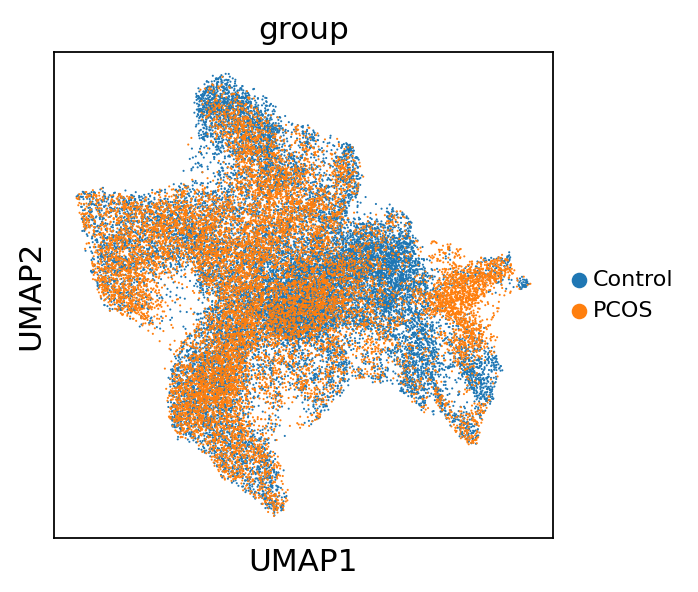

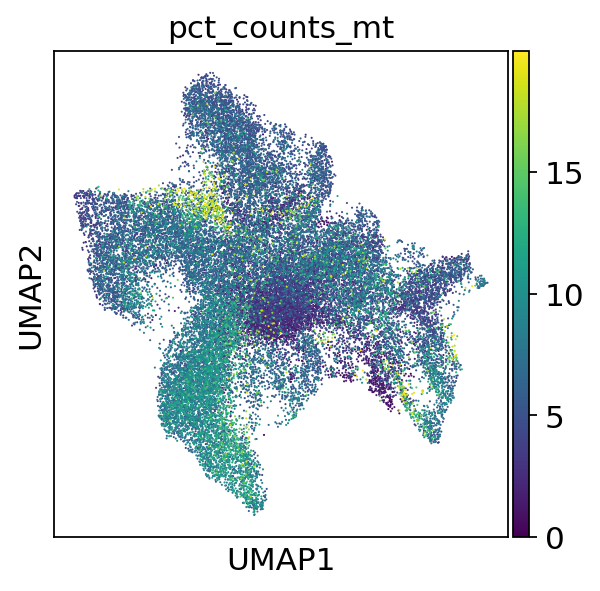

In [6]:
sc.pl.umap(adata_gr, color='group',
                    frameon=True,legend_fontsize=10,  show=False)
sc.pl.umap(adata_gr, color='pct_counts_mt',
                    frameon=True,legend_fontsize=10,  show=False)

In [7]:
### 从0.1开始聚类
[sc.tl.leiden(adata_gr, resolution=r, flavor="igraph", n_iterations=2, key_added=f'leiden_{r:.1f}') for r in [round(x, 2) for x in np.arange(0.1, 1.1, 0.1)]]

[None, None, None, None, None, None, None, None, None, None]

In [8]:
adata_gr

AnnData object with n_obs × n_vars = 33511 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden_0.5', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'Major_annotation', 'doublet_score', 'predicted_doublet', 'd_harmony_leiden_0.2', 'Major_annotation_d', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersec

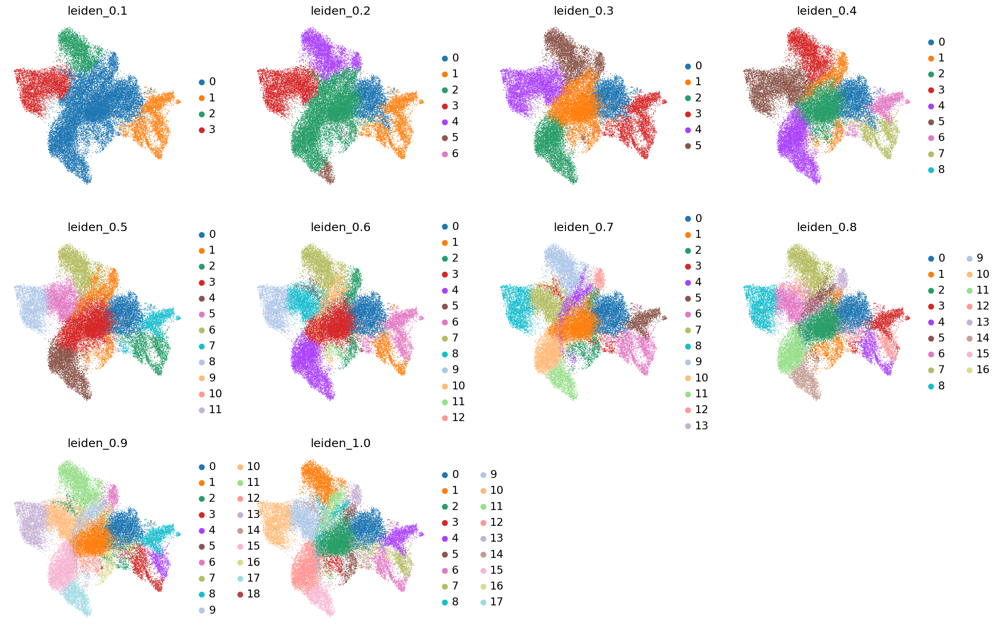

In [9]:
sc.pl.umap(adata_gr, color=[f'leiden_{r:.1f}' for r in np.round(np.arange(0.1, 1.1, 0.1), 2)],frameon=False)

In [12]:
adata_gr.obs['Gr_subannotation']=adata_gr.obs['leiden_0.5']

In [13]:
print(pd.crosstab(adata_gr.obs.group,adata_gr.obs.Gr_subannotation))

Gr_subannotation     0     1     2     3     4     5     6     7     8   9  \
group                                                                        
Control           3339  1552  1441  5062  2063  1486  2290   438  1380  66   
PCOS               781  1422   683  3231  2182  1524  1369  1374  1647  72   

Gr_subannotation  10  11  
group                     
Control           29  42  
PCOS               7  31  


In [14]:
### 差异分析
key_use='dea_Gr_subannotation_1'
adata_gr.uns['log1p']['base'] =None
sc.tl.rank_genes_groups(
    adata_gr, "Gr_subannotation", method="wilcoxon",key_added=key_use
    ,use_raw=True  #默认就是用这个
)

In [15]:
key_use='dea_Gr_subannotation_1'
### 导出差异分析结果
groups=adata_gr.uns[key_use]['names'].dtype.names

with pd.ExcelWriter('./08_颗粒细胞亚群细分_差异分析/08_Gr_subannotation_dea_results.xlsx') as writer:  #保存路径记得修改
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata_gr,group=group,key=key_use)
        df['group']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)



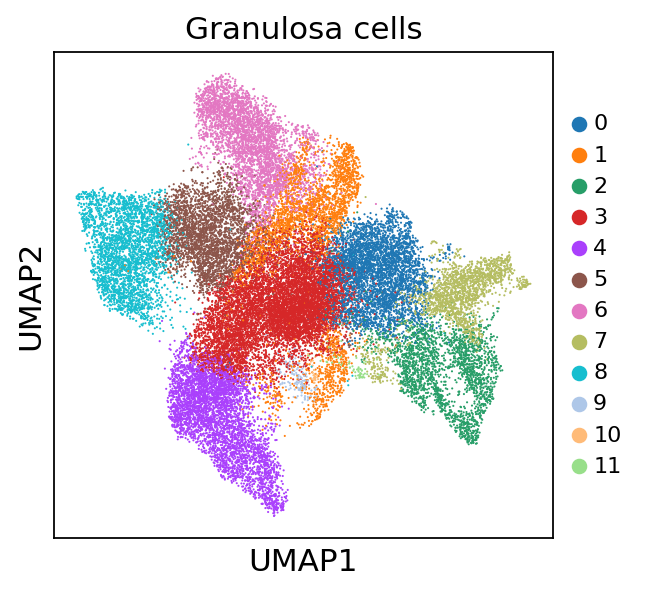

In [16]:
group_use="Gr_subannotation" #分群信息
sc.pl.umap(adata_gr, color=group_use,
                frameon=True,legend_fontsize=10
               , show=False
                   ,title='Granulosa cells'
                   )
plt.savefig("./figures/08_before_GC_umap.pdf", format="pdf", bbox_inches='tight')


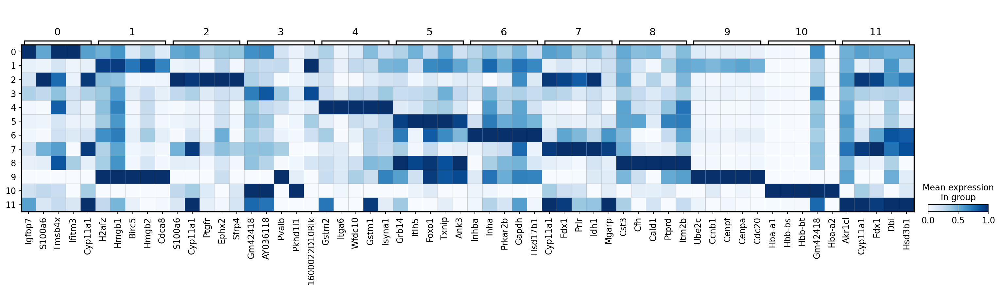

In [17]:
group_use="Gr_subannotation" #分群信息
# 确保分组信息是整数类型，并按顺序排序
# 确保分组信息是整数类型，并按顺序排序
#adata_gr.obs[group_use] = adata_gr.obs[group_use].astype('category')
#adata_gr.obs[group_use] = adata_gr.obs[group_use].cat.set_categories([str(i) for i in range(10)])

key_use='dea_Gr_subannotation_1' #差异分析key
group_use="Gr_subannotation" #分群信息
sc.pl.rank_genes_groups_matrixplot( 
    adata_gr,
    groupby=group_use,
    key=key_use,
    standard_scale="var",
    n_genes=5,
    show=False
    ,min_logfoldchange=1.25
    ,cmap='Blues'
    , dendrogram=False
)
plt.savefig("./figures/08_before_hb_markers_umap.pdf", format="pdf", bbox_inches='tight')


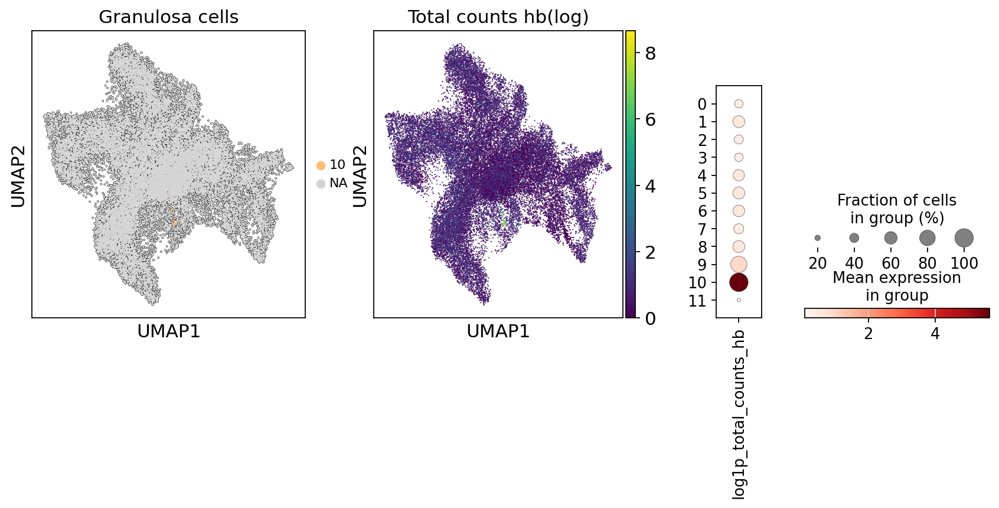

In [19]:
group_use="Gr_subannotation" #分群信息

#### 画图
fig, axs = plt.subplots(1,3,figsize=(13,4), gridspec_kw={'wspace':0.25})

ax1=sc.pl.umap(adata_gr, color=group_use,groups='10',
                frameon=True,legend_fontsize=10
               , show=False
               ,add_outline=True
                   ,title='Granulosa cells'
               ,ax=axs[0]
                   )
ax2=sc.pl.umap(adata_gr
                    ,color='log1p_total_counts_hb'
                    ,frameon=True
                    #,legend_fontsize=10
                    , show=False
                    ,title='Total counts hb(log)'
                    ,ax=axs[1])

ax3=sc.pl.dotplot(adata_gr,'log1p_total_counts_hb'
                  ,groupby='Gr_subannotation'
                  ,ax=axs[2]
                  , show=False

)

# 在每个子图上绘制UMAP
# 将图像保存为 PDF 文件
plt.savefig("./figures/08_before_hb_dot_umap.pdf", format="pdf", bbox_inches='tight')


In [20]:
adata_gr.write('./08_颗粒细胞亚群细分_差异分析/before_hb_gr_subgroup.h5ad')

### 去除hb亚群 重新注释

In [21]:
#### 重新读入数据

adata_gr=sc.read_h5ad('./08_颗粒细胞亚群细分_差异分析/before_hb_gr_subgroup.h5ad')


In [22]:
adata_a=adata_gr.raw.copy().to_adata()
adata_a.raw=adata_a.copy()  ### 保存标准化之后的矩阵
adata_a.layers['counts']=adata_gr.layers['counts'].copy()
adata_a=adata_a[adata_a.obs.Gr_subannotation!='10',:]

#sc.pp.highly_variable_genes(adata,min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata_a, flavor='seurat', batch_key='sample', n_top_genes=2000)
#adata_gr = adata_gr[:, adata_gr.var.highly_variable]
sc.pp.regress_out(adata_a, ["total_counts", "pct_counts_mt",'S_score', 'G2M_score'])
sc.pp.scale(adata_a, max_value=10)
sc.tl.pca(adata_a, svd_solver="arpack")
####去批次
sce.pp.harmony_integrate(adata_a,key='sample',basis='X_pca',plot_convergence=True)
sc.pp.neighbors(adata_a,use_rep='X_pca_harmony', n_neighbors=10, n_pcs=30)
sc.tl.umap(adata_a,random_state=42)

/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:705: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
2025-08-07 21:19:23,305 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-07 21:21:25,359 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-07 21:21:25,676 - harmonypy - INFO - Iteration 1 of 10
2025-08-07 21:21:55,346 - harmonypy - INFO - Iteration 2 of 10
2025-08-07 21:22:25,962 - harmonypy - INFO - Converged after 2 iterations


[<Axes: title={'center': 'group'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Gr_subannotation'}, xlabel='UMAP1', ylabel='UMAP2'>]

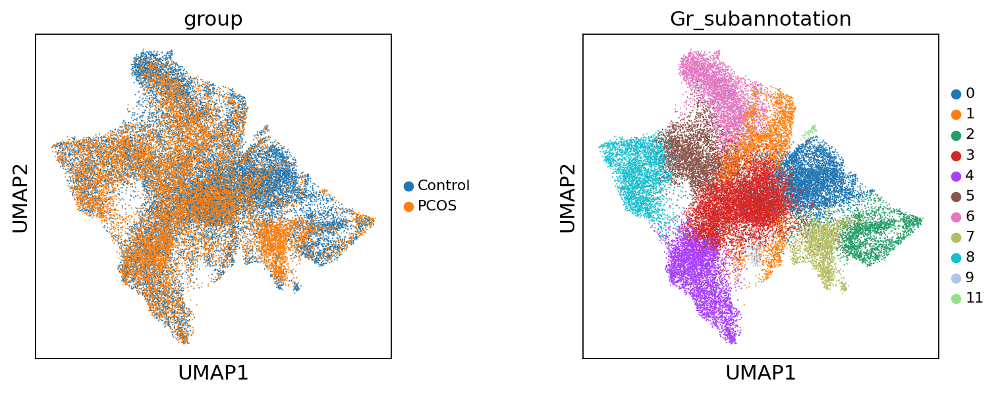

In [23]:
sc.pl.umap(adata_a, color=['group','Gr_subannotation'],
                    frameon=True,legend_fontsize=10,  show=False,wspace=0.4)


In [24]:
# 假设你想删除名为 'leiden_0.1', 'leiden_0.2' 等的列
columns_to_remove = [col for col in adata_a.obs.columns if col.startswith('leiden_')]

# 从 adata.obs 中删除这些列
adata_a.obs.drop(columns=columns_to_remove, inplace=True)

In [25]:
### 从0.1开始聚类
[sc.tl.leiden(adata_a, resolution=r, flavor="igraph", n_iterations=2, key_added=f'leiden_{r:.1f}') for r in [round(x, 2) for x in np.arange(0.1, 1.1, 0.1)]]

[None, None, None, None, None, None, None, None, None, None]

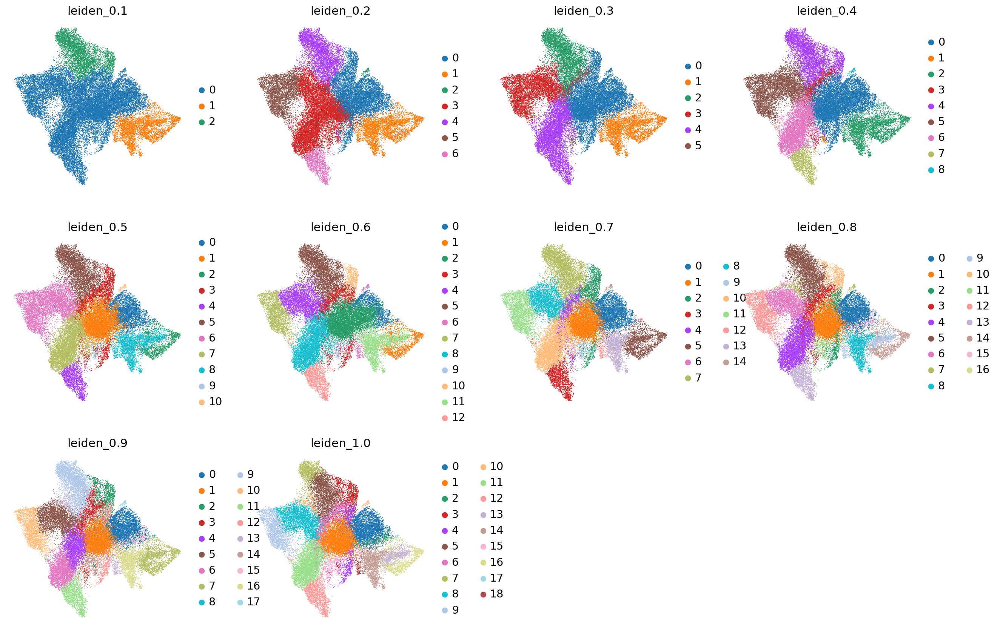

In [26]:
sc.pl.umap(adata_a, color=[f'leiden_{r:.1f}' for r in np.round(np.arange(0.1, 1.1, 0.1), 2)],frameon=False)

In [27]:
### annotation cell types
###手动注释结果以字典形式导回 

input_name="Gr_subannotation"  #手动注释的群 自己起名字列名叫啥


### 手动收集的经典marker
cl_annotation = {
    "3": "GC_1",  #Mural cells
    "0": "GC_4", #
    "5": "GC_2", 
    "1": "GC_3", #
    "2": "GC_0", # 
    "4": "GC_5", #
    #
}
#map 字典映射关系
adata_a.obs[input_name] = adata_a.obs['leiden_0.3'].map(cl_annotation) #新建一列叫["Major_annotation"]

In [29]:
group_use="Gr_subannotation"
adata_a.obs[group_use] = adata_a.obs[group_use].astype('category')
adata_a.obs[group_use] = adata_a.obs[group_use].cat.set_categories(['GC_'+str(i) for i in range(6)])


In [31]:
### 差异分析
adata_a.uns['log1p']['base'] =None
sc.tl.rank_genes_groups(
    adata_a, "Gr_subannotation", method="wilcoxon",key_added='dea_Gr_subannotation_1'
    ,use_raw=True  #默认就是用这个
)
### 导出差异分析结果
groups=adata_a.uns['dea_Gr_subannotation_1']['names'].dtype.names

with pd.ExcelWriter('./08_颗粒细胞亚群细分_差异分析/after_hb_Gr_subannotation_dea_results.xlsx') as writer:
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata_a,group=group,key='dea_Gr_subannotation_1')
        df['group']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)
    



In [36]:
print(pd.crosstab(adata_a.obs.group,adata_a.obs.Gr_subannotation))


Gr_subannotation  GC_0  GC_1  GC_2  GC_3  GC_4  GC_5
group                                               
Control           2673  2604   375  1996  7936  3575
PCOS              1820  2906   429  2068  3500  3593


[<Axes: title={'center': 'group'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Gr_subannotation'}, xlabel='UMAP1', ylabel='UMAP2'>]

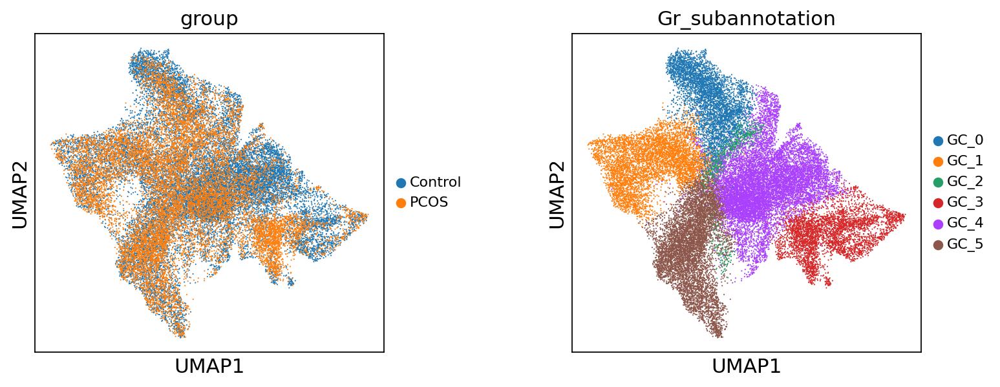

In [33]:
sc.pl.umap(adata_a, color=['group','Gr_subannotation'],
                    frameon=True,legend_fontsize=10,  show=False,wspace=0.4)


/tmp/ipykernel_1726895/2817372058.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby([cell_type, 'Gr_subannotation']).size().unstack(fill_value=0)


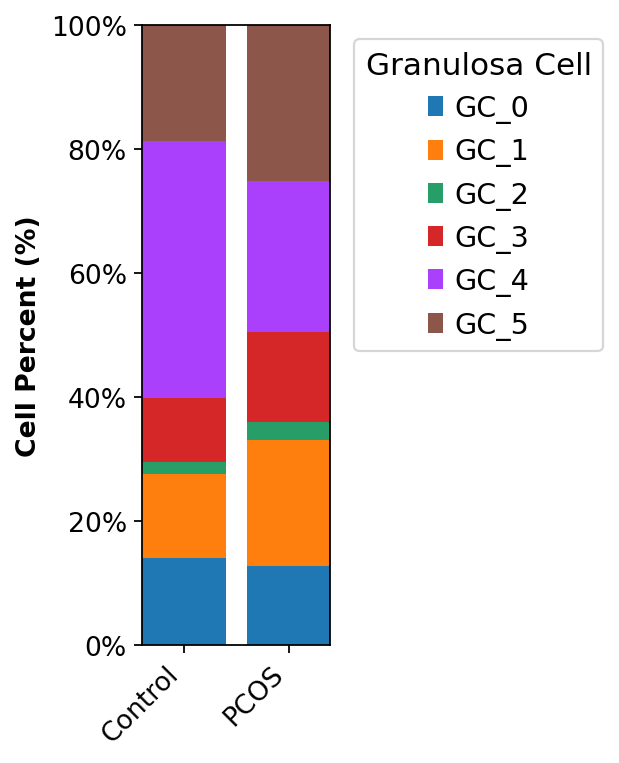

In [37]:
#### 细胞比例图

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
#plt.rcParams['font.family'] = 'Arial'
# 假设 adata 已经加载并包含了必要的 obs 信息
# 确保 'cell_type' 和 'sample' 在 adata.obs 中

cell_type='group'
fig_size=(4.2,5)

# 创建一个 DataFrame，包含 cell_type 和 sample 列
df = adata_a.obs[[cell_type, 'Gr_subannotation']]

# 计算每个样本中每种细胞类型的数量
cell_counts = df.groupby([cell_type, 'Gr_subannotation']).size().unstack(fill_value=0)

# 计算每个样本中每种细胞类型的百分比
cell_percentages = cell_counts.div(cell_counts.sum(axis=1), axis=0)

# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=fig_size)

# 使用 seaborn 的 stacked bar plot 功能 (需要通过累积和手动实现)
bottom = None
for idx, col in enumerate(cell_percentages.columns):
    if idx == 0:
        ax.bar(cell_percentages.index, cell_percentages[col], label=col)
        bottom = cell_percentages[col]
    else:
        ax.bar(cell_percentages.index, cell_percentages[col], bottom=bottom, label=col)
        bottom += cell_percentages[col]

# 设置图表标题和标签
#ax.set_title('',weight='bold',color='black',fontsize=12)
ax.set_xlabel(None,color='black',weight='bold',fontsize=12)
ax.set_ylabel('Cell Percent (%)',color='black',weight='bold',fontsize=12)
ax.grid(False)  # 完全移除网格线
# 或者
# ax.grid(True, linestyle='--')  # 将网格线变为虚线
# 旋转 x 轴标签 45 度并右对齐
plt.xticks(rotation=45, ha='right',color='black',fontsize=12) ##9e3741
plt.yticks(fontsize=12)
# 添加图例
plt.legend(title='Granulosa Cell', bbox_to_anchor=(1.05, 1), loc='upper left')
# 将图形两侧紧贴 y 轴
#ax.spines['left'].set_position(('data', -0.05))  # 调整左侧脊柱位置
#ax.spines['right'].set_visible(False)  # 隐藏右侧脊柱
#ax.spines['top'].set_visible(False)  # 隐藏顶部脊柱
# 修改 y 轴刻度标签为百分比格式（如 0% 到 100%）
def percent_formatter(x, pos):
    return f"{int(x * 100)}%"
ax.yaxis.set_major_formatter(mticker.FuncFormatter(percent_formatter))
# 可选：设置 y 轴刻度间隔为每 0.2（即 0%, 20%, ..., 100%）
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
# 设置 y 轴范围从 0 到 1，并且没有额外的扩展
ax.set_ylim(0, 1)
ax.margins(x=0)  # 消除 x 轴的空白区域
# 调整布局以避免遮挡
plt.tight_layout()

# 将图像保存为 PDF 文件
plt.savefig("./figures/08_Gr_cell_percent_group_plot.pdf", format="pdf", bbox_inches='tight')

# 显示图形
plt.show()


/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/a3d9h01010/miniconda3/envs/sc_ss_ov/lib/python3.10/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


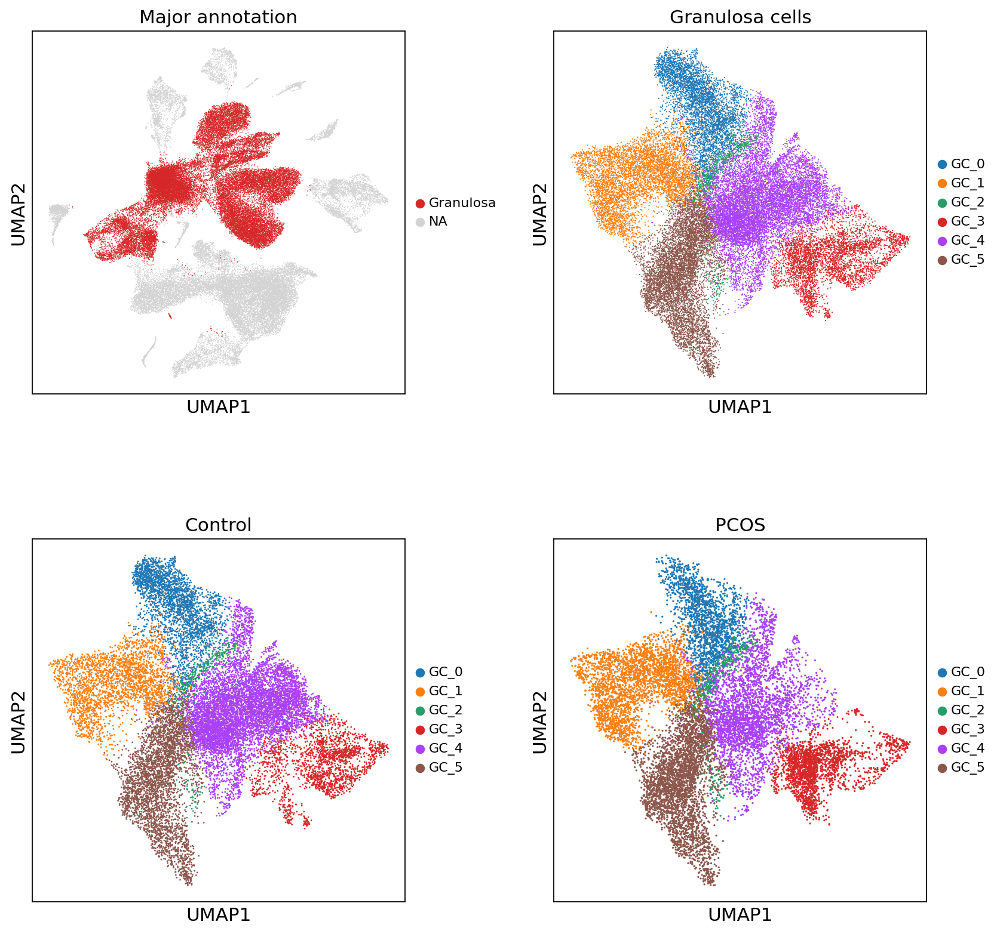

In [39]:
#### UMAP图
fig, axs = plt.subplots(2,2,figsize=(12,12), gridspec_kw={'wspace':0.4,'hspace':0.4})
# 在每个子图上绘制UMAP
sc.pl.umap(adata
           , color='Major_annotation_d'
           ,groups='Granulosa'
            ,frameon=True
           ,legend_fontsize=10
           , show=False
           ,title='Major annotation'
           ,ax=axs[0,0]
                   )

ax2_dict=sc.pl.umap(adata_a, color='Gr_subannotation'
                    ,title='Granulosa cells'
                    ,frameon=True,legend_fontsize=10,   ax=axs[0, 1], show=False)
ax3_dict=sc.pl.umap(adata_a[adata_a.obs.group=='Control'], color='Gr_subannotation'
                    ,title='Control'
                    ,frameon=True,legend_fontsize=10,   ax=axs[1, 0], show=False)
ax4_dict=sc.pl.umap(adata_a[adata_a.obs.group!='Control'], color='Gr_subannotation'
                    ,title='PCOS'
                    ,frameon=True,legend_fontsize=10,   ax=axs[1, 1], show=False)

# 将图像保存为 PDF 文件
plt.savefig("./figures/08_after_hb_cell_umap_output.pdf", format="pdf", bbox_inches='tight')


In [40]:
adata_a.write('./08_颗粒细胞亚群细分_差异分析/08_after_hb_Gr_subanndata.h5ad')

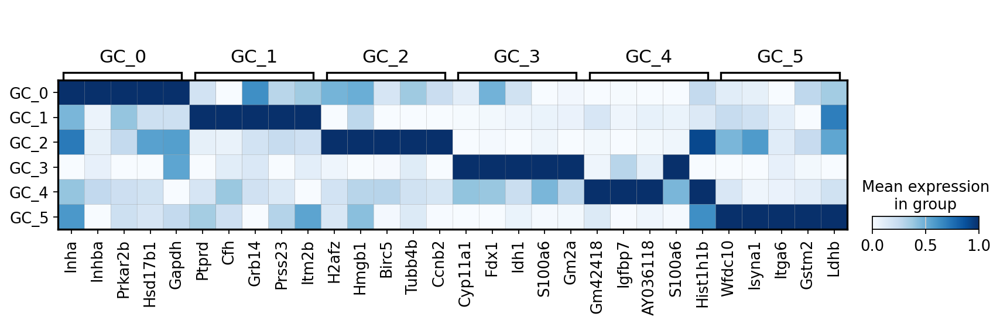

In [41]:
# 确保分组信息是整数类型，并按顺序排序
# 确保分组信息是整数类型，并按顺序排序
#adata_gr.obs[group_use] = adata_gr.obs[group_use].astype('category')
#adata_gr.obs[group_use] = adata_gr.obs[group_use].cat.set_categories([str(i) for i in range(10)])

key_use='dea_Gr_subannotation_1' #差异分析key
group_use="Gr_subannotation" #分群信息
sc.pl.rank_genes_groups_matrixplot( 
    adata_a,
    groupby=group_use,
    key=key_use,
    standard_scale="var",
    n_genes=5,
    show=False
    ,min_logfoldchange=1.25
    ,cmap='Blues'
    , dendrogram=False
)
plt.savefig("./figures/08_After_hb_markers_umap.pdf", format="pdf", bbox_inches='tight')


In [2]:
adata_a=sc.read_h5ad('./08_颗粒细胞亚群细分_差异分析/08_after_hb_Gr_subanndata.h5ad')